# import and setup

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy.spatial.distance import cdist
from pygsp import graphs, filters, plotting


In [38]:
# Make pandas display wider in this notebook
pd.set_option('display.width', 200)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

# quick learn of pygsp

/Users/ash/Library/CloudStorage/OneDrive-Nexus365/PHD/spatial data/wytham/wytham_rfid/.venv/lib/python3.12/site-packages/pygsp/plotting.py:610: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
  sc = ax.scatter(


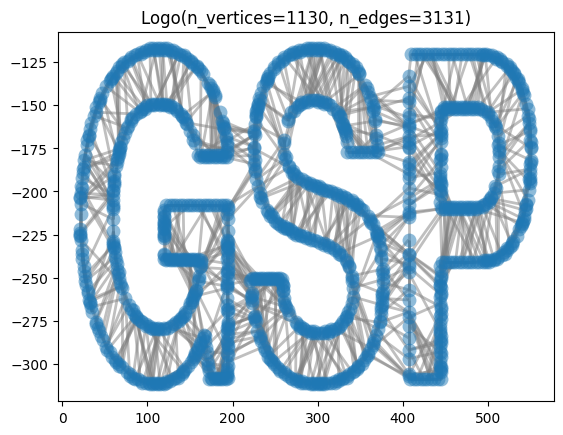

In [4]:
G = graphs.Logo() # Example graph of the GSP logo
G.compute_fourier_basis()  # Fourier to plot the eigenvalues.
# G.estimate_lmax() is otherwise sufficient.
fig, ax = G.plot()  # Plot the graph


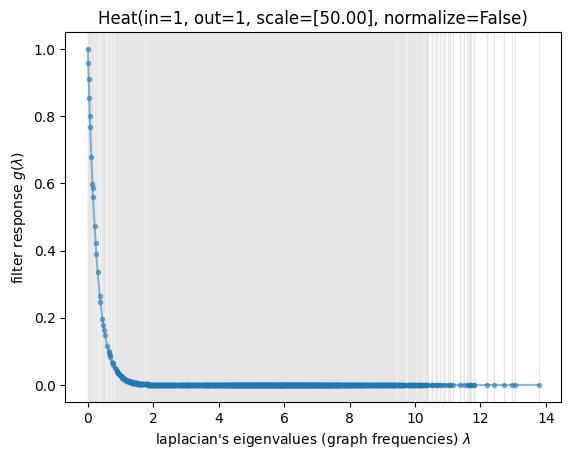

In [5]:
g = filters.Heat(G, scale=50) #heat filter on graph G with scale 50
fig, ax = g.plot() #plot the filter and the graphs eigenvalues in grey lines

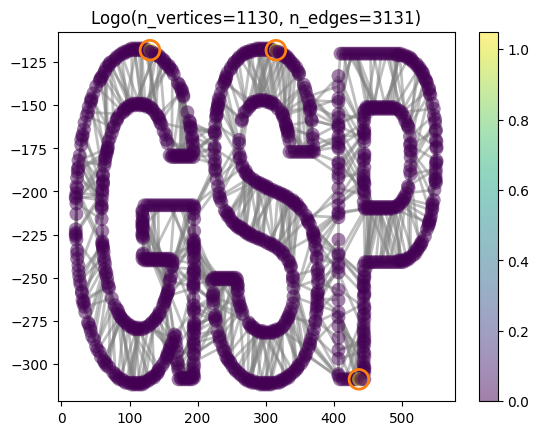

In [6]:
DELTAS = [20, 30, 1090]# example nodes to highlight (heat sources)
s = np.zeros(G.N) # signal on the graph (0 everywhere ... 
s[DELTAS] = 1 #except 1 at DELTAS)
fig, ax = G.plot(s, highlight=DELTAS)


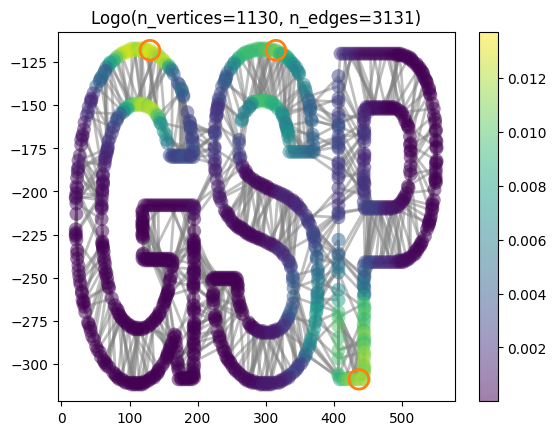

In [7]:
s = g.filter(s) # apply graph heat filter g to signal s, to get new signal s
fig, ax = G.plot(s, highlight=DELTAS)

# open and process data

In [39]:
PT_FILES = '/Users/ash/Library/CloudStorage/OneDrive-Nexus365/PHD/spatial data/wytham/RFID_DATA'

In [40]:
df_locations = pd.read_csv(f'{PT_FILES}/logger_locations.csv')
# 2012
df = pd.read_csv(f'{PT_FILES}/2012/records.csv')
df_ids = pd.read_csv(f'{PT_FILES}/2012/ids.csv')
# 2013
# df = pd.read_csv(f'{PT_FILES}/2013/records.csv')
# df_ids = pd.read_csv(f'{PT_FILES}/2013/ids.csv')
# 2014
# df = pd.read_csv(f'{PT_FILES}/2014/records.csv')
# df_ids = pd.read_csv(f'{PT_FILES}/2014/ids.csv')
# 2015
# df = pd.read_csv(f'{PT_FILES}/2015/records.csv')
# df_ids = pd.read_csv(f'{PT_FILES}/2015/ids.csv')

df = df.join(df_ids[['species','id']].set_index('id'), on='id', rsuffix='_id')


In [41]:
# Convert time to datetime once
if 'time_dt' not in df.columns:
    df['time_dt'] = pd.to_datetime(df['time'], errors='coerce')

In [42]:
df_process = df.dropna(subset=['time_dt']).sort_values(['id', 'time_dt']).copy() # drop records with no timestamp and sort by id and time

In [43]:
df_process = df_process[['id', 'location', 'species', 'time_dt']].reset_index()

In [44]:
df_process['time_diff'] = df_process.groupby('id')['time_dt'].diff().dt.total_seconds() # time difference in seconds between previous and current record

loc_changed = df_process['location'].ne(df_process.groupby('id')['location'].shift())# boolean series where location changes from previous record
df_process['is_new_visit'] = loc_changed.fillna(False)
df_process['is_arrival'] = df_process['is_new_visit'] #| (df_process.groupby('id').cumcount() == 0) # new visit or first record for id
# do the next-visit shift within each id to avoid cross-id leakage
df_process['is_departure'] = (
    df_process.groupby('id')['is_new_visit'].shift(-1, fill_value=True)
    | (df_process.groupby('id').cumcount(ascending=False) == 0)
)
df_arr_dep = df_process[df_process['is_arrival'] | df_process['is_departure']].copy() # keep only arrivals and departures

In [45]:
# Lookup table for distances between locations
D = pd.DataFrame(
    cdist(df_locations[['x','y']], df_locations[['x','y']], metric='euclidean'),
    index=df_locations['Name'], columns=df_locations['Name']
)

# speeds

In [15]:
df_arr_dep['prev_location'] = df_arr_dep.groupby('id')['location'].shift(1).dropna()
df_arr_dep['distance_m'] = df_arr_dep.apply(
    lambda r: (
        D.loc[str(r['location']).strip().upper(), str(r['prev_location']).strip().upper()]
        if pd.notna(r['location']) and pd.notna(r['prev_location'])
        and str(r['location']).strip().upper() in D.index
        and str(r['prev_location']).strip().upper() in D.columns
        else np.nan
    ),
    axis=1
)
# Only compute speed when the previous record belongs to the same individual and previous time is the same day as current time
prev_id = df_arr_dep.groupby('id')['id'].shift(1)
same_individual = df_arr_dep['id'].eq(prev_id)
prev_time = df_arr_dep.groupby('id')['time_dt'].shift(1)
same_day = df_arr_dep['time_dt'].dt.date.eq(prev_time.dt.date)
denom = df_arr_dep['time_diff'].replace(0, np.nan)
df_arr_dep['speed_m_s'] = np.where(same_individual & same_day, df_arr_dep['distance_m'] / denom, np.nan)
#     lambda row: D.loc[row['location'].upper(), row['prev_location'].upper()], axis=1
# )


In [16]:
df_arr_dep.head()

,index,id,location,species,time_dt,time_diff,is_new_visit,is_arrival,is_departure,prev_location,distance_m,speed_m_s
0,10414,c695905,1c,bluti,2011-12-03 08:34:37,NaN,True,True,False,NaN,NaN,NaN
9,18944,c695905,1c,bluti,2011-12-03 09:04:50,1.0,False,False,True,1c,0.000000,0.000000
10,32517,c695905,1d,bluti,2011-12-03 09:48:51,2641.0,True,True,False,1c,275.870519,0.104457
97,203745,c695905,1d,bluti,2011-12-04 10:57:23,994.0,False,False,True,1d,0.000000,NaN
98,210800,c695905,1c,bluti,2011-12-04 11:22:51,1528.0,True,True,False,1d,275.870519,0.180544


In [17]:
df_fast = df_arr_dep.copy()
df_fast['faster_than_20'] = df_fast['speed_m_s'] > 20
df_fast['keep'] = (df_fast['faster_than_20']==True) | (df_fast['faster_than_20'].shift(1, fill_value=False) | df_fast['faster_than_20'].shift(-1, fill_value=False))
df_fast_check = df_fast[df_fast['keep']].copy()
print(f"Number of rows with speed > 20 m/s or adjacent to such rows: {len(df_fast_check)}")
df_fast_check.head(20)

Number of rows with speed > 20 m/s or adjacent to such rows: 270


,index,id,location,species,time_dt,time_diff,is_new_visit,is_arrival,is_departure,prev_location,distance_m,speed_m_s,faster_than_20,keep
196079,1714583,l171445,2i,marti,2012-01-01 08:57:35,1.0,False,False,True,2i,0.000000,0.000000,False,True
196080,1714658,l171445,3b,marti,2012-01-01 08:57:48,13.0,True,True,False,2i,283.778082,21.829083,True,True
196085,1715895,l171445,3b,marti,2012-01-01 09:00:59,1.0,False,False,True,3b,0.000000,0.000000,False,True
196097,1719421,l171445,2i,marti,2012-01-01 09:09:05,1.0,False,False,True,2i,0.000000,0.000000,False,True
196098,1719429,l171445,3b,marti,2012-01-01 09:09:06,1.0,True,True,True,2i,283.778082,283.778082,True,True
196099,1719440,l171445,2i,marti,2012-01-01 09:09:07,1.0,True,True,True,3b,283.778082,283.778082,True,True
196100,1719441,l171445,3b,marti,2012-01-01 09:09:07,0.0,True,True,True,2i,283.778082,NaN,False,True
196101,1719453,l171445,2i,marti,2012-01-01 09:09:09,2.0,True,True,False,3b,283.778082,141.889041,True,True
196116,1719616,l171445,2i,marti,2012-01-01 09:09:24,1.0,False,False,True,2i,0.000000,0.000000,False,True
196399,2143973,l171445,3b,marti,2012-01-08 10:45:17,1.0,False,False,True,3b,0.000000,0.000000,False,True


In [18]:
max_speeds_ind = df_fast.groupby('id')['speed_m_s'].max()
max_speeds_species = df_fast.groupby('species')['speed_m_s'].max()
print("Maximum speeds by individual:")
print(max_speeds_ind)
print("\nMaximum speeds by species:")
print(max_speeds_species)

Maximum speeds by individual:
id
c695905    0.331177
c695958         NaN
e018488    0.868168
e018499    0.140041
e509370    0.227266
             ...   
y161532    0.000000
y161533    0.237507
y161534    0.941424
y161556         NaN
y161571    0.000000
Name: speed_m_s, Length: 2988, dtype: float64

Maximum speeds by species:
species
bluti    948.207062
coati    125.463446
greti    337.501471
marti    283.778082
nutha      0.907469
Name: speed_m_s, dtype: float64


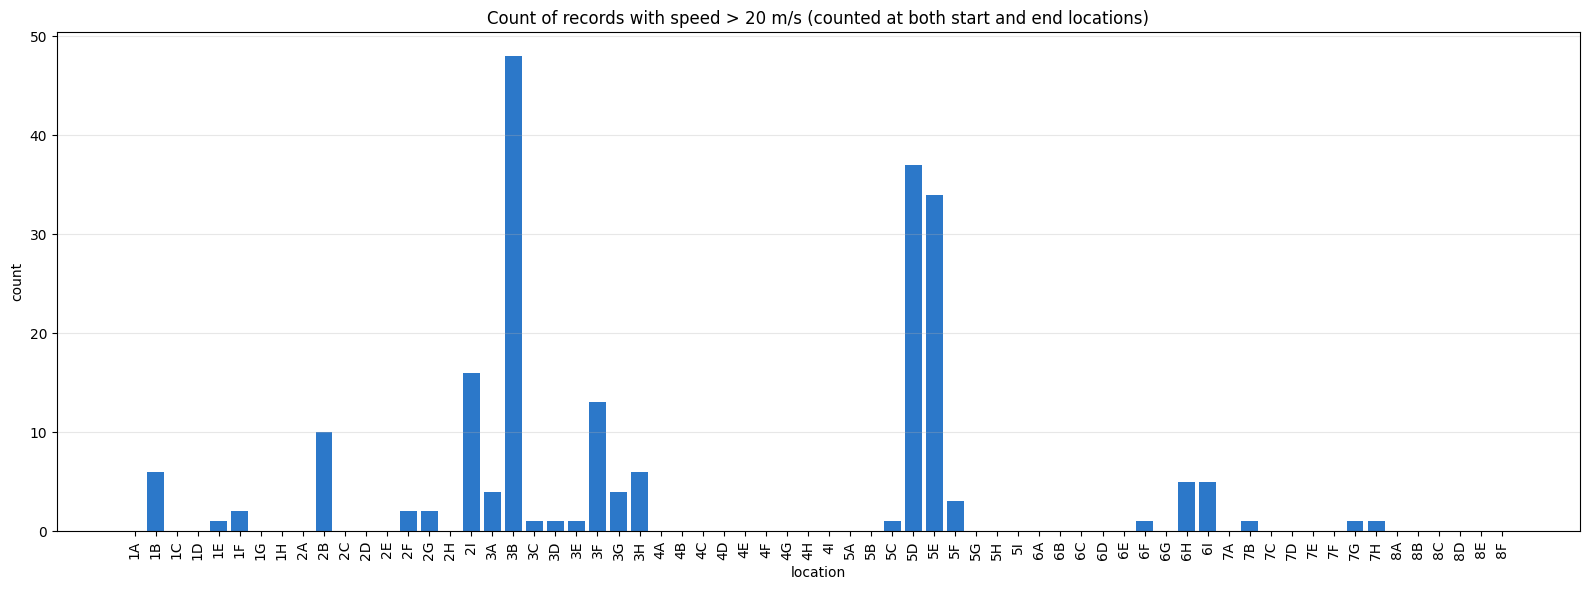

In [19]:
fast_locations = df_fast.loc[df_fast['faster_than_20'], ['location', 'prev_location']].copy()
# stack both columns into a single list of locations, normalize casing, drop missing
loc_series = pd.concat([fast_locations['location'], fast_locations['prev_location']], ignore_index=True)
loc_series = loc_series.dropna().astype(str).str.strip().str.upper()

# order by known locations from df_locations (normalize to upper for alignment)
known_locs = df_locations['Name'].astype(str).str.upper().tolist()
highspeed_counts = loc_series.value_counts().reindex(known_locs, fill_value=0)

# as a DataFrame (optional to inspect)
highspeed_counts_df = highspeed_counts.reset_index()
highspeed_counts_df.columns = ['location', 'high_speed_count']

# plot
fig, ax = plt.subplots(figsize=(16, 6))
ax.bar(highspeed_counts_df['location'], highspeed_counts_df['high_speed_count'],
    color="#2c78c9", edgecolor='none')
ax.set_title('Count of records with speed > 20 m/s (counted at both start and end locations)')
ax.set_xlabel('location')
ax.set_ylabel('count')
ax.grid(alpha=0.3, axis='y')
ax.tick_params(axis='x', rotation=90)
plt.tight_layout()

# location graph G_space_k_6

/Users/ash/Library/CloudStorage/OneDrive-Nexus365/PHD/spatial data/wytham/wytham_rfid/.venv/lib/python3.12/site-packages/pygsp/plotting.py:610: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
  sc = ax.scatter(


Text(0.5, 1.0, 'Feeders k-NN graph (k=6), sigma=314.18')

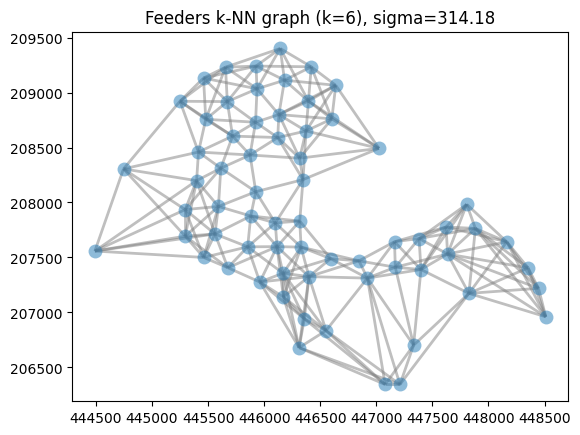

In [20]:
# Build a k-NN graph (k=6) over feeders using df_locations and D, with weights w_ij = exp(-d_ij / sigma)
# where sigma is the median distance among selected neighbor edges.

# Parameters
k = 6

# Distances as ndarray; do not modify D
dist = D.to_numpy(copy=True)
n = dist.shape[0]

# Exclude self-distances from neighbor search
np.fill_diagonal(dist, np.inf)

# Indices of k nearest neighbors for each node (directed kNN)
knn_idx = np.argpartition(dist, kth=k, axis=1)[:, :k]  # shape (n, k)

# Collect all selected neighbor distances to compute sigma
knn_dists = dist[np.arange(n)[:, None], knn_idx]
sigma = float(np.median(knn_dists[np.isfinite(knn_dists)]))

# Build directed weighted adjacency using the heat kernel
W = np.zeros((n, n), dtype=float)
weights = np.exp(-knn_dists / sigma)
for i in range(n):
    W[i, knn_idx[i]] = weights[i]

# Symmetrize to get an undirected graph
W = np.maximum(W, W.T)
np.fill_diagonal(W, 0.0)

# Coordinates aligned to the order of D's index
coords = (
    df_locations.set_index('Name')
    .loc[D.index, ['x', 'y']]
    .to_numpy()
)

# Create and plot the graph
G_space_k6 = graphs.Graph(W, coords=coords)
fig_k6, ax_k6 = G_space_k6.plot()
ax_k6.set_title(f'Feeders k-NN graph (k={k}), sigma={sigma:.2f}')

Text(0.5, 1.0, 'Feeders 6-NN graph, sigma=314.18 (edges colored by weight)')

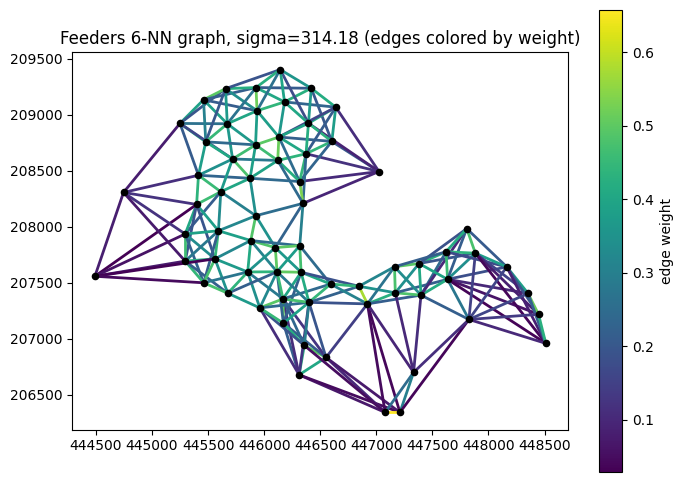

In [21]:
from matplotlib.collections import LineCollection

# Build a k-NN graph (k=6) over feeders using df_locations and D, with weights w_ij = exp(-d_ij / sigma)
# where sigma is the median distance among selected neighbor edges.

# Parameters
k = 6

# Distances as ndarray; do not modify D
dist = D.to_numpy(copy=True)
n = dist.shape[0]

# Exclude self-distances from neighbor search
np.fill_diagonal(dist, np.inf)

# Indices of k nearest neighbors for each node (directed kNN)
knn_idx = np.argpartition(dist, kth=k, axis=1)[:, :k]  # shape (n, k)

# Collect all selected neighbor distances to compute sigma
knn_dists = dist[np.arange(n)[:, None], knn_idx]
sigma = float(np.median(knn_dists[np.isfinite(knn_dists)]))

# Build directed weighted adjacency using the heat kernel
W = np.zeros((n, n), dtype=float)
weights = np.exp(-knn_dists / sigma)
for i in range(n):
    W[i, knn_idx[i]] = weights[i]

# Symmetrize to get an undirected graph
W = np.maximum(W, W.T)
np.fill_diagonal(W, 0.0)

# Coordinates aligned to the order of D's index
coords = (
    df_locations.set_index('Name')
    .loc[D.index, ['x', 'y']]
    .to_numpy()
)

# Create graph object (kept for later use if needed)
G_space_k6 = graphs.Graph(W, coords=coords)

# Plot with edges colored by weights

ii, jj = np.where(W > 0)
mask = ii < jj  # undirected unique edges
segments = np.stack([coords[ii[mask]], coords[jj[mask]]], axis=1)
edge_w = W[ii[mask], jj[mask]]

norm = plt.Normalize(vmin=float(edge_w.min()), vmax=float(edge_w.max()))
cmap = cm.viridis

fig_k6, ax_k6 = plt.subplots(figsize=(8, 6))
lc = LineCollection(segments, cmap=cmap, norm=norm, linewidths=2)
lc.set_array(edge_w)
ax_k6.add_collection(lc)
ax_k6.autoscale()

# nodes
ax_k6.scatter(coords[:, 0], coords[:, 1], s=20, c='k', zorder=3)

# colorbar
cb = plt.colorbar(lc, ax=ax_k6)
cb.set_label('edge weight')

ax_k6.set_aspect('equal', adjustable='box')
# ax_k6.set_xticks([])
# ax_k6.set_yticks([])
ax_k6.set_title(f'Feeders {6}-NN graph, sigma={sigma:.2f} (edges colored by weight)')

# Mobility graph, G_flow

/Users/ash/Library/CloudStorage/OneDrive-Nexus365/PHD/spatial data/wytham/wytham_rfid/.venv/lib/python3.12/site-packages/pygsp/plotting.py:610: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
  sc = ax.scatter(
/var/folders/fv/6lp893hd21qcv8d6dcgrwb4w0000gp/T/ipykernel_1008/2591693875.py:111: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  denom_s = df.loc[df['species'] == sp, 'time_dt'].dt.floor('H').nunique()
/var/folders/fv/6lp893hd21qcv8d6dcgrwb4w0000gp/T/ipykernel_1008/2591693875.py:111: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  denom_s = df.loc[df['species'] == sp, 'time_dt'].dt.floor('H').nunique()
/var/folders/fv/6lp893hd21qcv8d6dcgrwb4w0000gp/T/ipykernel_1008/2591693875.py:111: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  denom_s = df.loc[df['species'] == sp, 'time_

All-hours exposure (hour bins): 274
Built G_flow_all, 12 hourly graphs (6-18), and 51 hour×species graphs.


/var/folders/fv/6lp893hd21qcv8d6dcgrwb4w0000gp/T/ipykernel_1008/2591693875.py:111: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  denom_s = df.loc[df['species'] == sp, 'time_dt'].dt.floor('H').nunique()


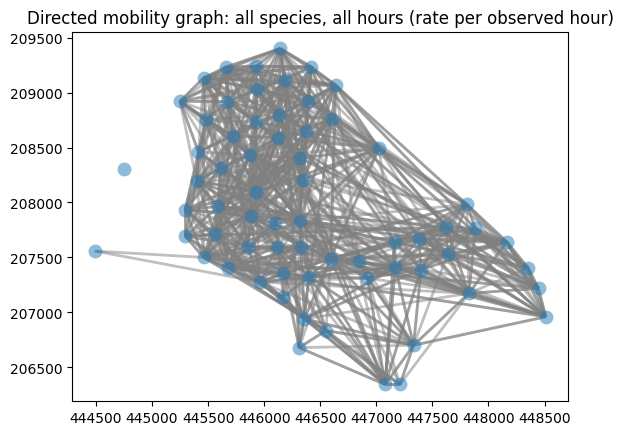

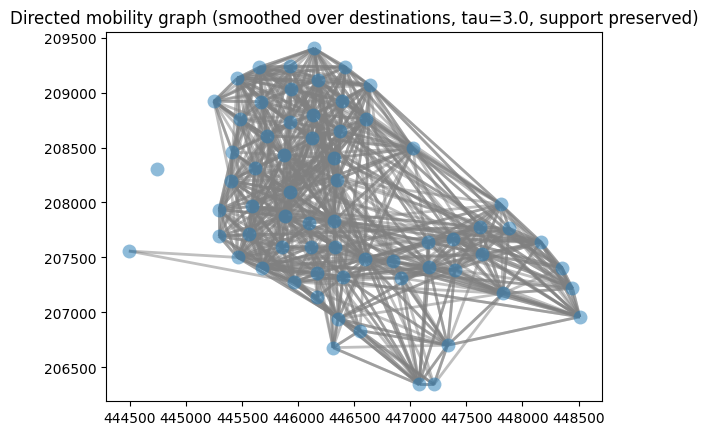

In [32]:
# Build directed mobility graphs from observed transitions (speed > 0)

# Normalize locations and keep valid transitions
_trans = (
    df_arr_dep.loc[
        (df_arr_dep['speed_m_s'] > 0)
        & df_arr_dep['prev_location'].notna()
        & df_arr_dep['location'].notna(),
        ['prev_location', 'location', 'species', 'time_dt']
    ]
    .assign(
        src=lambda d: d['prev_location'].astype(str).str.strip().str.upper(),
        dst=lambda d: d['location'].astype(str).str.strip().str.upper(),
        hour=lambda d: d['time_dt'].dt.hour,
        date=lambda d: d['time_dt'].dt.date,
    )
)
_valid = set(D.index.astype(str))
_trans = _trans[_trans['src'].isin(_valid) & _trans['dst'].isin(_valid)]

# Node ordering and mapping (aligned with D)
_names = list(D.index.astype(str))
_name_to_idx = {name: i for i, name in enumerate(_names)}

def _W_from_counts(counts, denom):
    W = np.zeros((len(_names), len(_names)), dtype=float)
    if denom and denom > 0 and len(counts) > 0:
        rates = counts / float(denom)
        for (src, dst), val in rates.items():
            W[_name_to_idx[src], _name_to_idx[dst]] = float(val)
    return W

# Global exposure: number of unique observed hour bins in df (any species)
_exposure_hours_all = df['time_dt'].dt.floor('h').nunique()

# All species, all hours
_counts_all = _trans.groupby(['src', 'dst']).size()
W_flow_all = _W_from_counts(_counts_all, _exposure_hours_all)
G_flow_all = graphs.Graph(W_flow_all, coords=coords)  # directed (asymmetric W)
fig_flow_all, ax_flow_all = G_flow_all.plot()
ax_flow_all.set_title('Directed mobility graph: all species, all hours (rate per observed hour)')



# Smooth flow weights over the spatial kNN graph without adding new edges.
# We smooth each row (outgoing flows from a source) as a graph signal over destinations,
# using the undirected spatial graph G_space_k6, then preserve the original edge support.

G_space_k6.compute_fourier_basis()  # safe if already computed
tau = 3.0  # smoothing strength (increase for more smoothing)
# PyGSP API compatibility: some versions expect 'tau', others 't', or positional.
try:
    heat = filters.Heat(G_space_k6, tau=tau)
except TypeError:
    try:
        heat = filters.Heat(G_space_k6, t=tau)
    except TypeError:
        heat = filters.Heat(G_space_k6, tau)

F = W_flow_all.copy()
# Smooth across destinations only (columns are signals => use F.T)
F_smooth = heat.filter(F.T).T

# Preserve original support to avoid creating new edges
support = (W_flow_all > 0).astype(float)
F_smooth_masked = F_smooth * support

# Renormalize each row to keep the same total outgoing rate
row_sum_orig = W_flow_all.sum(axis=1, keepdims=True)
row_sum_new = F_smooth_masked.sum(axis=1, keepdims=True)
scale = np.divide(row_sum_orig, row_sum_new, out=np.ones_like(row_sum_orig), where=row_sum_new > 0)
F_smooth_masked *= scale

filtered_W_flow_all = F_smooth_masked
filtered_G_flow_all = graphs.Graph(filtered_W_flow_all, coords=coords)
fig, ax = filtered_G_flow_all.plot()
ax.set_title(f'Directed mobility graph (smoothed over destinations, tau={tau}, support preserved)')



# Per-hour graphs (all species), restrict to 6..18
_hours = list(range(6, 19))
G_flow_by_hour = {}
W_flow_by_hour = {}
for h in _hours:
    c_h = _trans.loc[_trans['hour'] == h].groupby(['src', 'dst']).size()
    # exposure: number of distinct days with any record in that hour
    denom_h = df.loc[df['time_dt'].dt.hour == h, 'time_dt'].dt.date.nunique()
    W_h = _W_from_counts(c_h, denom_h)
    if np.any(W_h):  # only create non-empty graphs
        G_flow_by_hour[h] = graphs.Graph(W_h, coords=coords)
    W_flow_by_hour[h] = W_h

# Per-species x hour graphs, restrict to 6..18
_species = sorted(_trans['species'].dropna().unique().tolist())
G_flow_by_hour_species = {}
W_flow_by_hour_species = {}
for sp in _species:
    for h in _hours:
        sel = (_trans['species'] == sp) & (_trans['hour'] == h)
        c_sh = _trans.loc[sel].groupby(['src', 'dst']).size()
        # exposure: number of distinct days this species has any record in that hour
        denom_sh = df.loc[(df['species'] == sp) & (df['time_dt'].dt.hour == h), 'time_dt'].dt.date.nunique()
        W_sh = _W_from_counts(c_sh, denom_sh)
        if np.any(W_sh):
            G_flow_by_hour_species[(h, sp)] = graphs.Graph(W_sh, coords=coords)
        W_flow_by_hour_species[(h, sp)] = W_sh

# Optional: per-species (all hours) graphs
G_flow_by_species = {}
W_flow_by_species = {}
for sp in _species:
    c_s = _trans.loc[_trans['species'] == sp].groupby(['src', 'dst']).size()
    # exposure: number of unique observed hour bins for this species
    denom_s = df.loc[df['species'] == sp, 'time_dt'].dt.floor('H').nunique()
    W_s = _W_from_counts(c_s, denom_s)
    if np.any(W_s):
        G_flow_by_species[sp] = graphs.Graph(W_s, coords=coords)
    W_flow_by_species[sp] = W_s

# Export small summary for sanity
print(f"All-hours exposure (hour bins): {_exposure_hours_all}")
print(f"Built G_flow_all, {len(G_flow_by_hour)} hourly graphs (6-18), and {len(G_flow_by_hour_species)} hour×species graphs.")

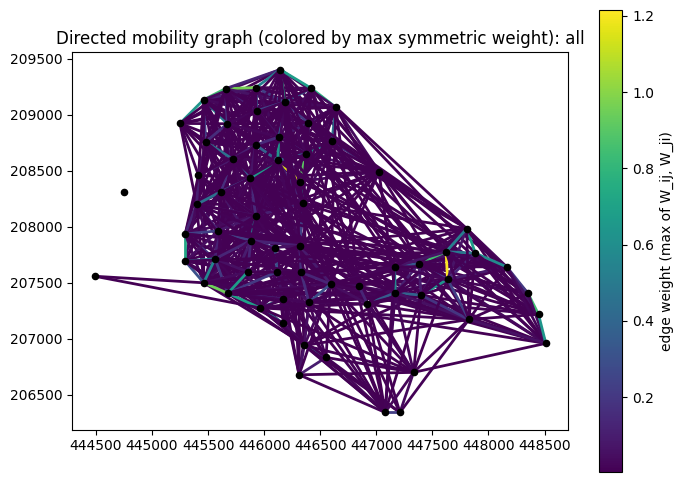

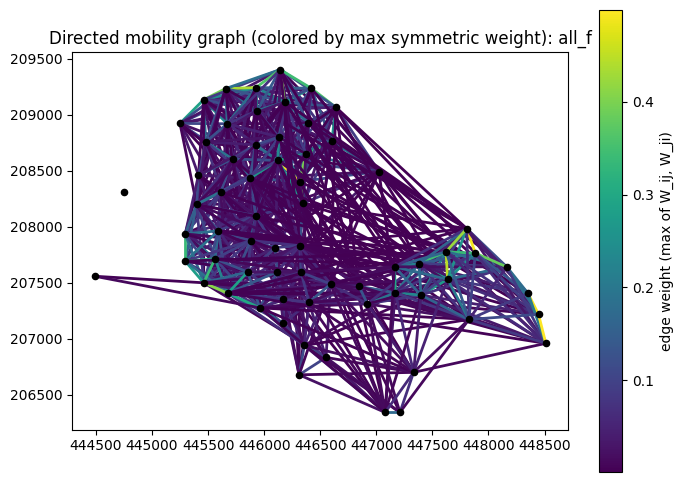

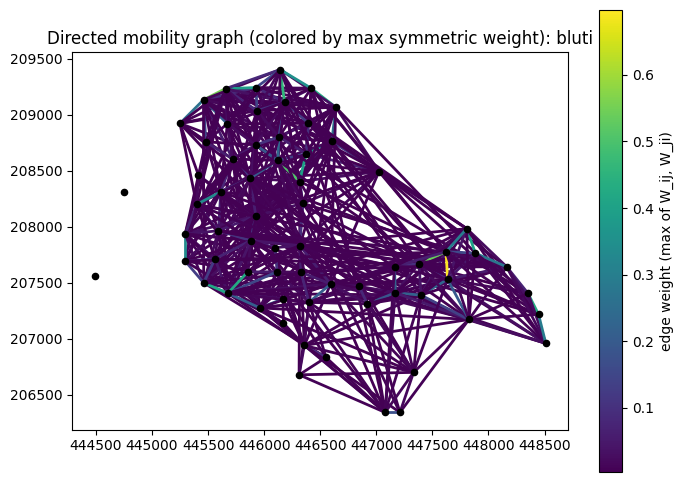

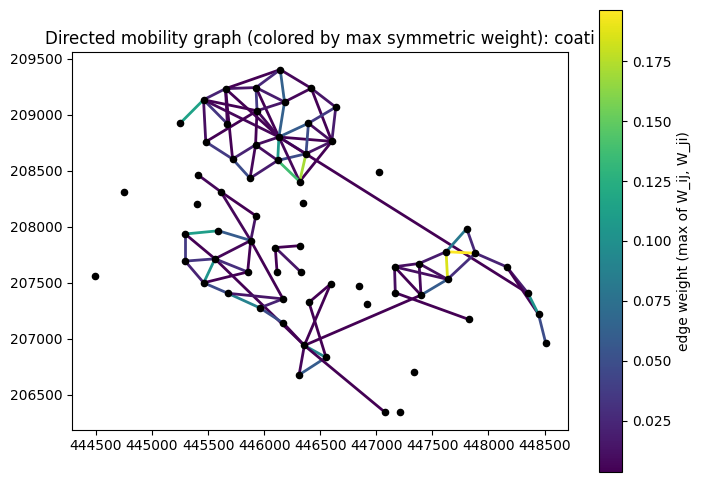

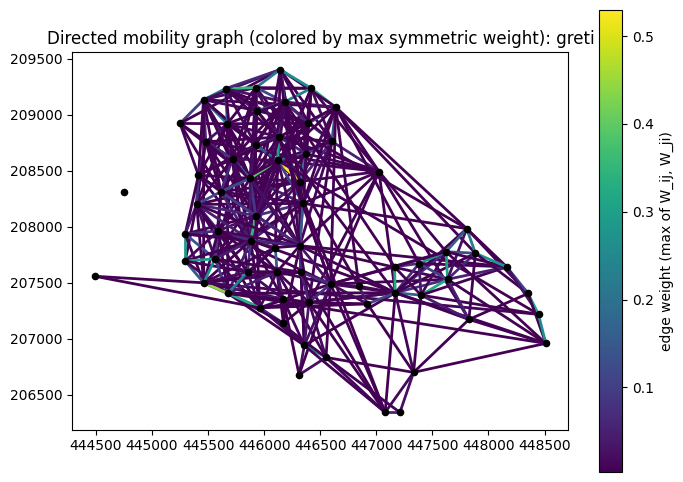

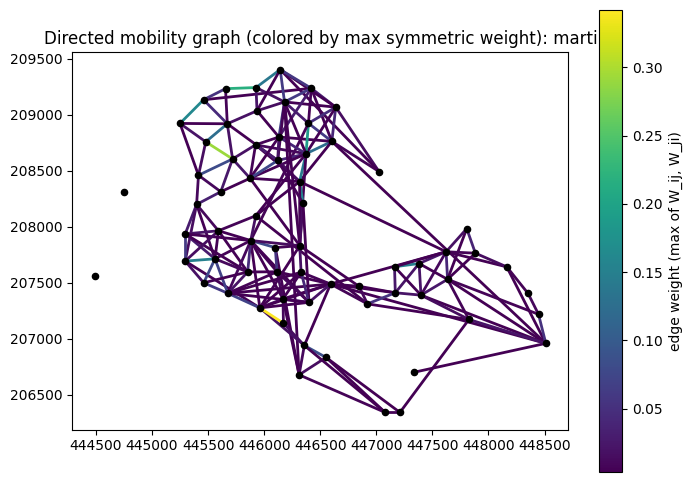

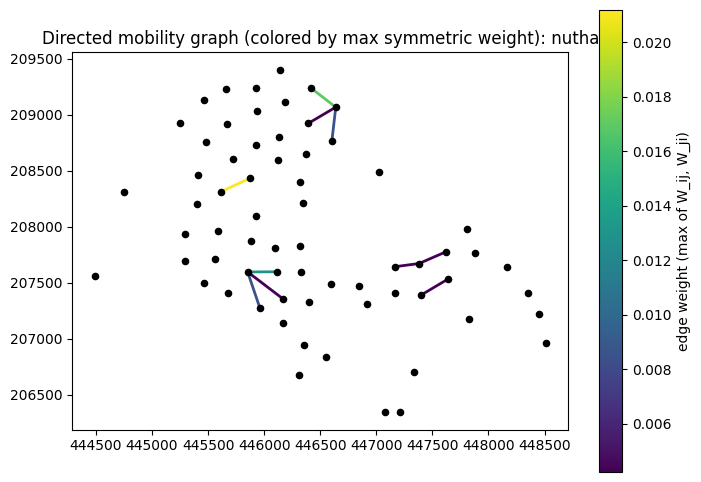

In [34]:
# Plot species mobility with edges colored by max(W_ij, W_ji)
def plot_species_mobility(species):
    if species == 'all':
        W_dir = W_flow_all
    elif species == 'all_f':
        W_dir = filtered_W_flow_all
    else:
        W_dir = W_flow_by_species[species]
    C = np.maximum(W_dir, W_dir.T)  # color value per undirected edge

    ii, jj = np.where(np.triu(C, k=1) > 0)
    edge_vals = C[ii, jj]

    fig, ax = plt.subplots(figsize=(8, 6))
    if edge_vals.size:
        segments = np.stack([coords[ii], coords[jj]], axis=1)
        norm = plt.Normalize(vmin=float(edge_vals.min()), vmax=float(edge_vals.max()))
        lc = LineCollection(segments, cmap=cm.viridis, norm=norm, linewidths=2)
        lc.set_array(edge_vals)
        ax.add_collection(lc)
        plt.colorbar(lc, ax=ax, label='edge weight (max of W_ij, W_ji)')

    # nodes
    ax.scatter(coords[:, 0], coords[:, 1], s=20, c='k', zorder=3)
    ax.autoscale()
    ax.set_aspect('equal', adjustable='box')
    ax.set_title(f'Directed mobility graph (colored by max symmetric weight): {species}')
    return fig, ax
fig_sp, ax_sp = plot_species_mobility('all')
fig_sp, ax_sp = plot_species_mobility('all_f')
fig_sp, ax_sp = plot_species_mobility('bluti')
fig_sp, ax_sp = plot_species_mobility('coati')
fig_sp, ax_sp = plot_species_mobility('greti')
fig_sp, ax_sp = plot_species_mobility('marti')
fig_sp, ax_sp = plot_species_mobility('nutha')

In [24]:
from matplotlib.animation import FuncAnimation, PillowWriter
from matplotlib.collections import LineCollection
import os

def make_species_hour_gif(species, hours=None, out_path=None, fps=1, figsize=(8, 6)):
    """
    Create a GIF showing the per-hour directed mobility graph for a species,
    with edges colored by max(W_ij, W_ji). One frame per hour (slow playback via low fps).

    Params:
      species: str, species code (e.g., 'marti')
      hours: iterable of ints; defaults to the hours used in this notebook (_hours)
      out_path: output gif path; defaults to f'{species}_per_hour.gif'
      fps: frames per second for the GIF (lower = slower)
      figsize: matplotlib figure size

    Returns:
      str: path to the saved GIF.
    """
    sp = str(species).lower()
    hrs = list(_hours if hours is None else hours)
    if out_path is None:
        out_path = f'plots/graph_{sp}_per_hour.gif'
        os.makedirs(os.path.dirname(out_path), exist_ok=True)

    # Precompute frames (segments and values) and global color scale
    frames = []
    vmax = 0.0
    for h in hrs:
        W_dir = W_flow_by_hour_species.get((h, sp))
        if W_dir is None or not np.any(W_dir):
            frames.append((h, None, None))
            continue
        C = np.maximum(W_dir, W_dir.T)
        ii_h, jj_h = np.where(np.triu(C, k=1) > 0)
        if ii_h.size == 0:
            frames.append((h, None, None))
            continue
        segs = np.stack([coords[ii_h], coords[jj_h]], axis=1)
        vals = C[ii_h, jj_h]
        frames.append((h, segs, vals))
        vmax = max(vmax, float(vals.max()))
    if vmax <= 0:
        vmax = 1.0  # avoid zero-range color scale

    # Setup figure and static elements
    fig, ax = plt.subplots(figsize=figsize)
    ax.scatter(coords[:, 0], coords[:, 1], s=20, c='k', zorder=3)
    ax.set_aspect('equal', adjustable='box')
    xmin, ymin = coords.min(axis=0)
    xmax, ymax = coords.max(axis=0)
    pad = 0.05 * max(xmax - xmin, ymax - ymin)
    ax.set_xlim(xmin - pad, xmax + pad)
    ax.set_ylim(ymin - pad, ymax + pad)

    norm = plt.Normalize(vmin=0.0, vmax=vmax)
    lc = LineCollection([], cmap=cm.viridis, norm=norm, linewidths=2)
    lc.set_array(np.array([]))
    ax.add_collection(lc)
    cb = plt.colorbar(lc, ax=ax)
    cb.set_label('edge weight (max of W_ij, W_ji)')

    def init():
        lc.set_segments([])
        lc.set_array(np.array([]))
        ax.set_title(f'{sp} mobility by hour')
        return (lc,)

    def update(i):
        h, segs, vals = frames[i]
        if segs is None:
            lc.set_segments([])
            lc.set_array(np.array([]))
        else:
            lc.set_segments(segs)
            lc.set_array(vals)
        ax.set_title(f'{sp} mobility at hour {h:02d}')
        return (lc,)

    anim = FuncAnimation(fig, update, frames=len(frames), init_func=init, blit=False)
    try:
        writer = PillowWriter(fps=max(1, int(fps)))
        anim.save(out_path, writer=writer)
    finally:
        plt.close(fig)
    return out_path

# Example usage:
gif_path = make_species_hour_gif('nutha', fps=1)
gif_path

'plots/graph_nutha_per_hour.gif'

# Co-activity graph G_co

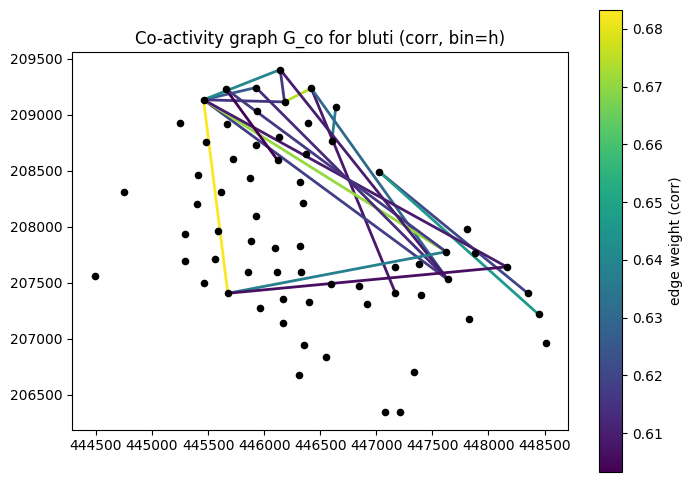

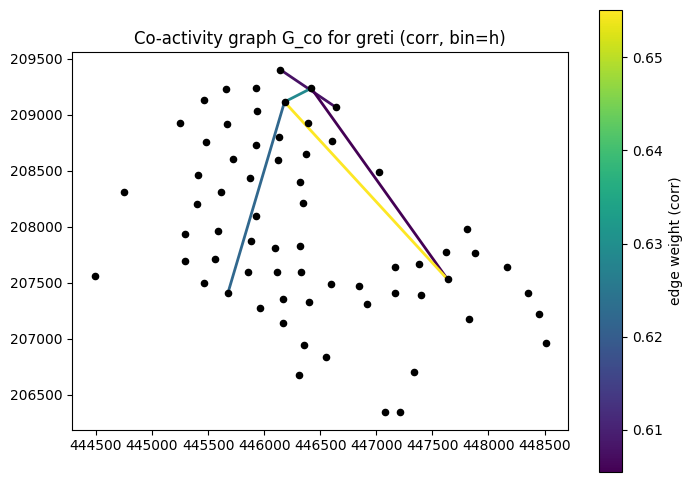

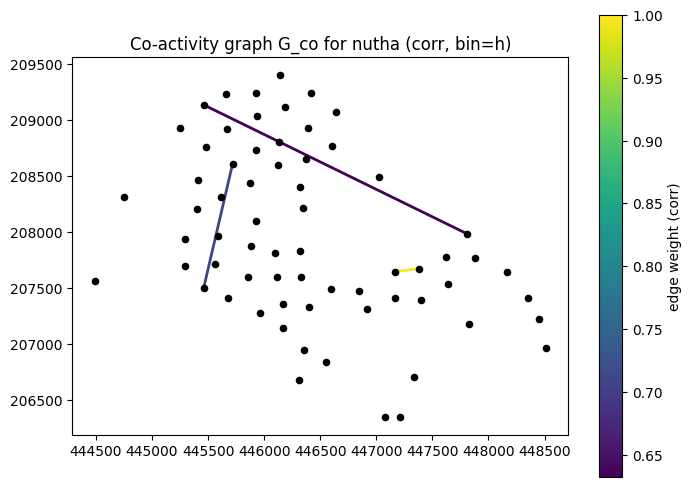

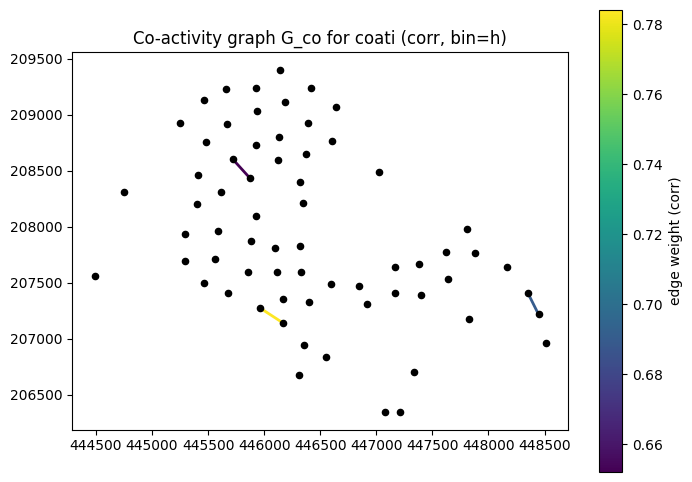

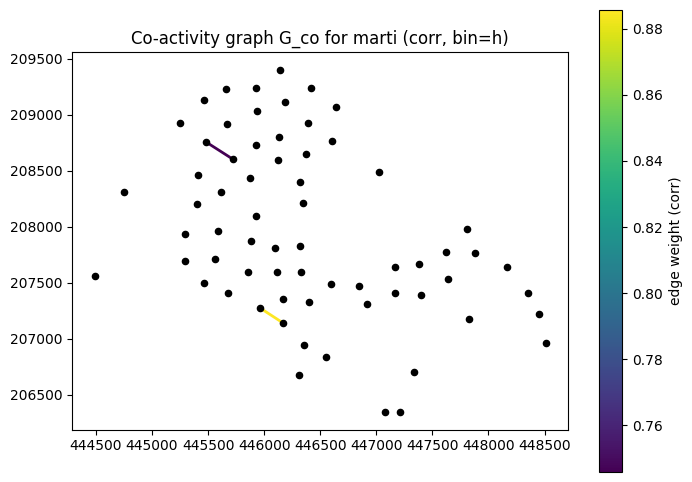

In [36]:
from scipy.signal import coherence

# Build an undirected co-activity graph G_co from correlation (or coherence) between feeders' visit-rate time series.

# Parameters
time_bin = 'h'          # bin size for visit-rate (e.g., 'H', '30T', '15T')
method = 'corr'         # 'corr' or 'coherence'
r_min = 0.4             # minimum edge weight (threshold); only used for 'corr'
k_prune = 6          # optionally keep top-k edges per node (e.g., 6); set None to disable
species = 'bluti'  # e.g., 'nutha' to restrict to one species; set None for all species

def co_activity_graph(df_arr_dep, D, coords, time_bin='h', method='corr', r_min=None, k_prune=None, species=None):
    # 1) Build per-feeder arrival count time series (visit-rate) for specified species
    df_sel = df_arr_dep
    if species is not None:
        df_sel = df_arr_dep[df_arr_dep['species'] == species]
    arrivals = (
        df_sel.loc[df_sel['is_arrival'], ['time_dt', 'location']]
        .dropna(subset=['time_dt', 'location'])
        .assign(
            loc=lambda d: d['location'].astype(str).str.strip().str.upper(),
            t=lambda d: d['time_dt'].dt.floor(time_bin)
        )
    )

    # restrict to known feeders in D (columns aligned to D.index order)
    feeders = D.index.astype(str)
    arrivals = arrivals[arrivals['loc'].isin(feeders)]

    visit_counts = (
        arrivals
        .groupby(['t', 'loc'])
        .size()
        .unstack(fill_value=0)
        .reindex(columns=feeders, fill_value=0)
        .sort_index()
    )

    # ensure a continuous time index (fill missing bins with zeros)
    if not visit_counts.empty:
        full_idx = pd.date_range(visit_counts.index.min(), visit_counts.index.max(), freq=time_bin)
        visit_counts = visit_counts.reindex(full_idx, fill_value=0)
    else:
        # fallback to zero-matrix if no arrivals
        visit_counts = pd.DataFrame(0, index=pd.Index([], name='t'), columns=feeders)

    # 2) Pairwise similarity matrix
    m = len(feeders)
    W_co = np.zeros((m, m), dtype=float)

    if method == 'coherence':
        # frequency-domain co-activity: average magnitude-squared coherence
        X = visit_counts.to_numpy(dtype=float)
        T = X.shape[0]
        for i in range(m):
            xi = X[:, i]
            for j in range(i + 1, m):
                xj = X[:, j]
                if xi.sum() == 0 or xj.sum() == 0:
                    val = 0.0
                else:
                    _, Cxy = coherence(xi, xj, nperseg=min(256, max(8, T)))
                    val = float(np.nanmean(Cxy))
                W_co[i, j] = W_co[j, i] = val
    else:
        # time-domain co-activity: Pearson correlation of binned visit rates
        R = visit_counts.corr(method='pearson').to_numpy()
        R = np.nan_to_num(R, nan=0.0)
        np.fill_diagonal(R, 0.0)
        # keep positive correlations only and threshold
        W_co = np.clip(R, 0.0, 1.0)
        if r_min is not None and r_min > 0:
            W_co[W_co < r_min] = 0.0

    # 3) Optional sparsification by top-k per node (symmetrized)
    if k_prune is not None and k_prune > 0 and m > 0:
        idx_sorted = np.argsort(W_co, axis=1)[:, ::-1]
        keep = np.zeros_like(W_co, dtype=bool)
        for i in range(m):
            top_j = idx_sorted[i, :min(k_prune, m)]
            keep[i, top_j] = True
        W_co = np.where(keep | keep.T, W_co, 0.0)

    # 4) Symmetrize and zero diagonal (ensure undirected)
    W_co = np.maximum(W_co, W_co.T)
    np.fill_diagonal(W_co, 0.0)

    # 5) Build graph and plot edges colored by weight
    G_co = graphs.Graph(W_co, coords=coords)

    # Plot like previous weighted-edge visuals
    ii, jj = np.where(W_co > 0)
    mask = ii < jj
    edge_vals = W_co[ii[mask], jj[mask]]

    fig_co, ax_co = plt.subplots(figsize=(8, 6))
    if edge_vals.size:
        segs = np.stack([coords[ii[mask]], coords[jj[mask]]], axis=1)
        norm = plt.Normalize(vmin=float(edge_vals.min()), vmax=float(edge_vals.max()))
        lc = LineCollection(segs, cmap=cm.viridis, norm=norm, linewidths=2)
        lc.set_array(edge_vals)
        ax_co.add_collection(lc)
        cb = plt.colorbar(lc, ax=ax_co)
        cb.set_label(f"edge weight ({'coherence' if method=='coherence' else 'corr'})")

    # nodes
    ax_co.scatter(coords[:, 0], coords[:, 1], s=20, c='k', zorder=3)
    ax_co.autoscale()
    ax_co.set_aspect('equal', adjustable='box')
    ax_co.set_title(f"Co-activity graph G_co for {species} ({method}, bin={time_bin})")

    # Expose key artifacts
    W_coherence_or_corr = W_co            # adjacency matrix used
    visit_counts_hourly = visit_counts    # binned time series used
    return fig_co, ax_co, G_co, W_coherence_or_corr, visit_counts_hourly

fig_co, ax_co, G_co, W_co, visit_counts = co_activity_graph(
    df_arr_dep, D, coords, time_bin='h', method='corr', r_min=0.6, k_prune=4, species='bluti'
)
fig_co, ax_co, G_co, W_co, visit_counts = co_activity_graph(
    df_arr_dep, D, coords, time_bin='h', method='corr', r_min=0.6, k_prune=4, species='greti'
)
fig_co, ax_co, G_co, W_co, visit_counts = co_activity_graph(
    df_arr_dep, D, coords, time_bin='h', method='corr', r_min=0.6, k_prune=4, species='nutha'
)
fig_co, ax_co, G_co, W_co, visit_counts = co_activity_graph(
    df_arr_dep, D, coords, time_bin='h', method='corr', r_min=0.6, k_prune=4, species='coati'
)
fig_co, ax_co, G_co, W_co, visit_counts = co_activity_graph(
    df_arr_dep, D, coords, time_bin='h', method='corr', r_min=0.6, k_prune=4, species='marti'
)


# presence graph - G_pres

In [50]:
df_pres = df.dropna(subset=['time_dt']).sort_values(['id', 'time_dt']).copy() # drop records with no timestamp and sort by id and time
df_pres.head()

,id,location,time,antenna_number,species,time_dt
10414,c695905,1c,2011-12-03 08:34:37,1,bluti,2011-12-03 08:34:37
10418,c695905,1c,2011-12-03 08:34:38,1,bluti,2011-12-03 08:34:38
10566,c695905,1c,2011-12-03 08:35:11,1,bluti,2011-12-03 08:35:11
10571,c695905,1c,2011-12-03 08:35:12,1,bluti,2011-12-03 08:35:12
11425,c695905,1c,2011-12-03 08:38:14,1,bluti,2011-12-03 08:38:14


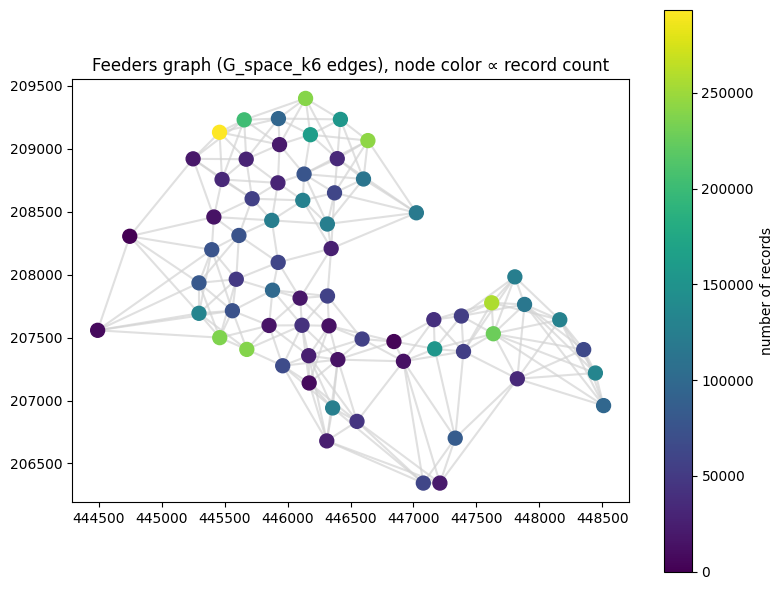

In [60]:
# compute number of records per feeder (aligned to D/coords order)
loc_counts = (
    df['location']
    .dropna()
    .astype(str).str.strip().str.upper()
    .value_counts()
    .reindex(D.index.astype(str), fill_value=0)
)

# build edge segments from G_space_k6 adjacency
W_sp = G_space_k6.W  # sparse adjacency
ii, jj = W_sp.nonzero()
mask = ii < jj  # undirected unique edges
segments = np.stack([coords[ii[mask]], coords[jj[mask]]], axis=1)

# plot: edges (light gray) and nodes colored by record count
fig, ax = plt.subplots(figsize=(8, 6))
lc = LineCollection(segments, colors='lightgray', linewidths=1.5, alpha=0.7)
ax.add_collection(lc)

# nodes with color proportional to counts
counts_vals = loc_counts.to_numpy()
norm_counts = plt.Normalize(vmin=0, vmax=float(counts_vals.max()) if counts_vals.size else 1.0)
sc = ax.scatter(coords[:, 0], coords[:, 1], s=100, c=counts_vals, cmap=cm.viridis, norm=norm_counts, zorder=3)

cb = plt.colorbar(sc, ax=ax)
cb.set_label('number of records')

ax.set_aspect('equal', adjustable='box')
ax.autoscale()
ax.set_title('Feeders graph (G_space_k6 edges), node color ∝ record count')
plt.tight_layout()



In [64]:
from matplotlib.collections import LineCollection
import os

# GIF of average records per hour-of-day (6–18), nodes colored by average count, edges from G_space_k6

def make_avg_records_hour_gif(hours=range(6, 19), out_path='plots/avg_records_per_hour.gif', fps=1, figsize=(10, 8), species=None):
    # Normalize locations and prepare hourly-date counts
    df_rec = df.dropna(subset=['time_dt', 'location']).copy()
    if species is not None:
        df_rec = df_rec[df_rec['species'] == species]
    df_rec['loc'] = df_rec['location'].astype(str).str.strip().str.upper()
    df_rec['hod'] = df_rec['time_dt'].dt.hour
    df_rec['date'] = df_rec['time_dt'].dt.date
    hrs = list(hours)

    # Restrict to known feeders and requested hours
    feeders = D.index.astype(str)
    df_rec = df_rec[df_rec['loc'].isin(feeders) & df_rec['hod'].isin(hrs)]

    # Count records per (hour-of-day, date, location)
    counts = (
        df_rec.groupby(['hod', 'date', 'loc'])
        .size()
        .rename('count')
        .reset_index()
    )

    # Pivot to (hod, date) x feeders; fill missing combos with 0
    pivot = counts.pivot_table(index=['hod', 'date'], columns='loc', values='count', fill_value=0)
    pivot = pivot.reindex(columns=feeders, fill_value=0)

    # Ensure all (hour, date) combos exist between min/max dates for fair averaging
    if not df_rec.empty:
        all_dates = pd.date_range(df_rec['time_dt'].dt.normalize().min(), df_rec['time_dt'].dt.normalize().max(), freq='D').date
    else:
        all_dates = []
    full_index = pd.MultiIndex.from_product([hrs, all_dates], names=['hod', 'date'])
    if len(full_index):
        pivot = pivot.reindex(full_index, fill_value=0)

    # Precompute per-hour average vectors and global color scale
    frames = []
    vmax = 0.0
    for h in hrs:
        if (h in pivot.index.get_level_values(0)):
            df_h = pivot.loc[h] if pivot.index.nlevels == 2 else pivot
            # df_h is DataFrame indexed by date, columns=feeders
            vec = df_h.mean(axis=0).to_numpy(dtype=float)
        else:
            vec = np.zeros(len(feeders), dtype=float)
        frames.append((h, vec))
        if vec.size:
            vmax = max(vmax, float(np.nanmax(vec)))
    if vmax <= 0:
        vmax = 1.0

    # Build edge segments from G_space_k6
    W_sp = G_space_k6.W
    ii, jj = W_sp.nonzero()
    mask = ii < jj
    segs = np.stack([coords[ii[mask]], coords[jj[mask]]], axis=1)

    # Figure setup
    os.makedirs(os.path.dirname(out_path), exist_ok=True)

    fig, ax = plt.subplots(figsize=figsize)

    # Edges (light gray)
    lc = LineCollection(segs, colors='lightgray', linewidths=1.5, alpha=0.7)
    ax.add_collection(lc)

    # Nodes colored by average count
    norm = plt.Normalize(vmin=0.0, vmax=vmax)
    init_vals = frames[0][1] if frames else np.zeros(len(feeders))
    sc_nodes = ax.scatter(coords[:, 0], coords[:, 1], s=100, c=init_vals, cmap=cm.viridis, norm=norm, zorder=3)
    cb = plt.colorbar(sc_nodes, ax=ax)
    cb.set_label('average records per hour-of-day')

    ax.set_aspect('equal', adjustable='box')
    ax.autoscale()
    ax.set_title('Average records per hour-of-day')

    # Animation callbacks
    def init():
        sc_nodes.set_array(init_vals)
        ax.set_title(f'Average {species} records at hour 06')
        return (sc_nodes,)

    def update(i):
        h, vec = frames[i]
        sc_nodes.set_array(vec)
        ax.set_title(f'Average {species} records at hour {h:02d}')
        return (sc_nodes,)

    anim = FuncAnimation(fig, update, frames=len(frames), init_func=init, blit=False)
    try:
        writer = PillowWriter(fps=max(1, int(fps)))
        anim.save(out_path, writer=writer)
    finally:
        plt.close(fig)
    return out_path

# Create the GIF for hours 6..18
species = [None, 'bluti', 'coati', 'marti', 'greti', 'nutha']
gif_paths_avg = []
for sp in species:
    gif_path_avg = make_avg_records_hour_gif(hours=range(6, 19), out_path=f'plots/avg_{sp}_records_per_hour.gif', fps=1, species=sp)
    gif_paths_avg.append(gif_path_avg)
gif_path_avg

'plots/avg_nutha_records_per_hour.gif'

In [ ]:
from matplotlib.animation import FuncAnimation, PillowWriter

def make_total_records_per_day_gif(out_path='plots/total_records_per_day.gif', fps=1, figsize=(10, 8), species=None):
    # Prepare daily totals per feeder (aligned to D/coords order)
    df_rec = df.dropna(subset=['time_dt', 'location']).copy()
    if species is not None:
        df_rec = df_rec[df_rec['species'] == species]
    df_rec['loc'] = df_rec['location'].astype(str).str.strip().str.upper()
    df_rec['date'] = df_rec['time_dt'].dt.normalize().dt.date

    feeders = D.index.astype(str)
    df_rec = df_rec[df_rec['loc'].isin(feeders)]

    daily_counts = (
        df_rec.groupby(['date', 'loc'])
        .size()
        .rename('count')
        .reset_index()
    )

    pivot = daily_counts.pivot_table(index='date', columns='loc', values='count', fill_value=0)
    pivot = pivot.reindex(columns=feeders, fill_value=0)

    # Only include dates where there is data
    dates = list(pivot.index)

    # Precompute frames and global color scale
    frames = []
    vmax = 0.0
    for d in dates:
        vec = pivot.loc[d].to_numpy(dtype=float)
        frames.append((d, vec))
        if vec.size:
            vmax = max(vmax, float(np.nanmax(vec)))
    if vmax <= 0:
        vmax = 1.0

    # Use precomputed edge segments if available; otherwise derive from G_space_k6
    try:
        segs = segments
    except NameError:
        W_sp = G_space_k6.W
        ii, jj = W_sp.nonzero()
        mask = ii < jj
        segs = np.stack([coords[ii[mask]], coords[jj[mask]]], axis=1)

    # Figure setup
    os.makedirs(os.path.dirname(out_path), exist_ok=True)
    fig, ax = plt.subplots(figsize=figsize)

    lc = LineCollection(segs, colors='lightgray', linewidths=1.5, alpha=0.7)
    ax.add_collection(lc)

    norm = plt.Normalize(vmin=0.0, vmax=vmax)
    init_vals = frames[0][1] if frames else np.zeros(len(feeders))
    sc_nodes = ax.scatter(coords[:, 0], coords[:, 1], s=100, c=init_vals, cmap=cm.viridis, norm=norm, zorder=3)
    cb = plt.colorbar(sc_nodes, ax=ax)
    cb.set_label('total records per day')

    ax.set_aspect('equal', adjustable='box')
    ax.autoscale()
    ax.set_title(f'Total records on {dates[0]}' if dates else 'Total records per day')

    def init():
        sc_nodes.set_array(init_vals)
        return (sc_nodes,)

    def update(i):
        d, vec = frames[i]
        sc_nodes.set_array(vec)
        ax.set_title(f'Total records on {d}')
        return (sc_nodes,)

    anim = FuncAnimation(fig, update, frames=len(frames), init_func=init, blit=False)
    try:
        writer = PillowWriter(fps=max(1, int(fps)))
        anim.save(out_path, writer=writer)
    finally:
        plt.close(fig)
    return out_path

# Create the GIF of total records per day (only days with data)
gif_path_total = make_total_records_per_day_gif(out_path='plots/total_records_per_day.gif', fps=1)
gif_path_total


'plots/total_records_per_day.gif'